#### Name: 

# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt


### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [5]:
g = 9.8 #gravitational acceleration

#Defining our velocity equation
def v(t,b,m,v0):
    vter = m*g/b
    return (v0-vter)*np.exp(-b/m * t) + vter



#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [27]:
#Defining our time array and constants
t_actual = np.arange(0,100+2,2)
v0 = 0
b = 0.1
m = 1.0

#velocity array
v_actual = v(t_actual,b,m,v0)

#### Step 3: 
Make a plot of the results. 

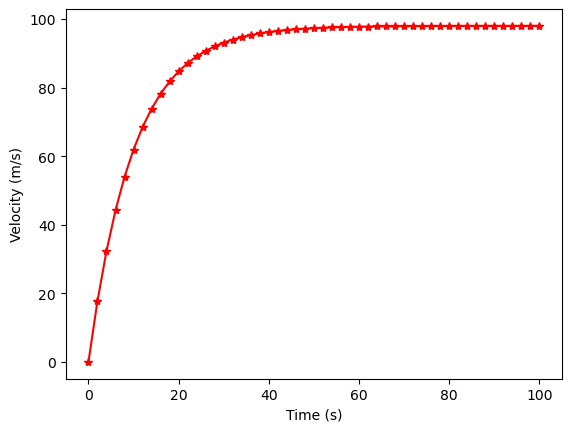

In [28]:
#Plotting results
plt.plot(t_actual,v_actual,"*r-")
#Making it look nice
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [29]:
#defining f(v)=dv/dt
def f(v):
    return g-(b/m)*v
#defining a general euler's method for a given time array, step size, initial conditions, and function
def euler(t,h,v0,f):
    v = np.zeros(len(t))
    for i in range(len(t)):
        v[i] = v0
        v0 += h*f(v[i])
    return v

#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

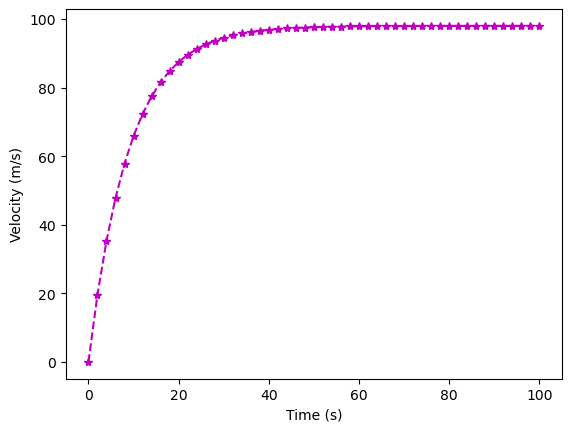

In [ ]:
#Defining constants and arrays
t_eul = np.arange(0,102,2)
v0 = 0
b = 0.1
m = 1.0
h = 2
v_eul = euler(t_eul,h,v0,f) #velocity result of euler's method

#Plotting our results
plt.plot(t_eul,v_eul,"*m--")
#Making it look nice
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

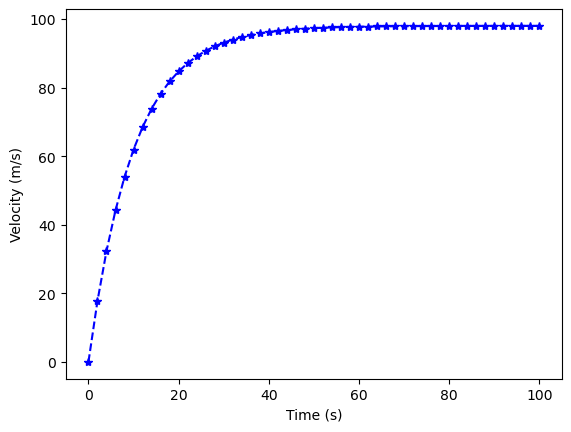

In [ ]:
#defining our RK4 method
def RK4(t,h,v0,f):
    v = np.zeros(len(t))
    for i in range(len(t)):
        v[i] = v0
        k1 = h*f(v[i])
        k2 = h*f(v[i]+k1/2)
        k3 = h*f(v[i]+k2/2)
        k4 = h*f(v[i]+k3)
        v0 += (k1+2*k2+2*k3+k4)/6
    return v

#Defining our constants and arrays
t_rk4 = np.arange(0,102,2)
v0 = 0
b = 0.1
m = 1.0
h = 2
v_rk4 = RK4(t_rk4,h,v0,f) #velocity result of RK4 method

#Plotting our results
plt.plot(t_rk4,v_rk4,"*b--")
#Making it look nice
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

I believe that all the results agree with each other, as they generally have the same end behavior and appear to look the same. This is likely because we are using a number of steps that is computationally unnecessary for the level of accuracy we are looking for.

C:\Users\cbake\AppData\Local\Temp\ipykernel_12608\1636299974.py:2: RuntimeWarning: invalid value encountered in divide
  RK4_err = np.log10(np.abs(v_rk4-v_actual)/np.abs(v_actual))
C:\Users\cbake\AppData\Local\Temp\ipykernel_12608\1636299974.py:3: RuntimeWarning: invalid value encountered in divide
  Eul_err = np.log10(np.abs(v_eul-v_actual)/np.abs(v_actual))


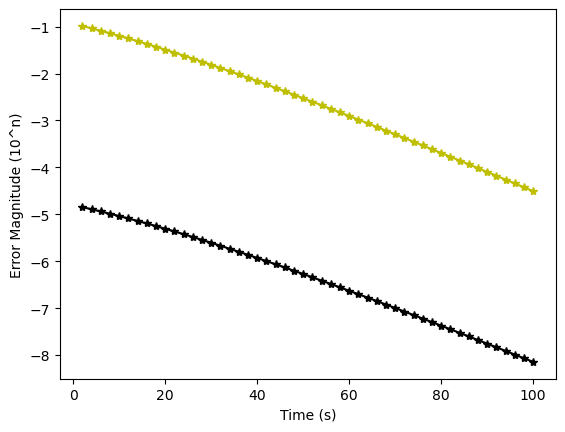

In [36]:
#logarithm of the relative error of the two methods
RK4_err = np.log10(np.abs(v_rk4-v_actual)/np.abs(v_actual))
Eul_err = np.log10(np.abs(v_eul-v_actual)/np.abs(v_actual))

#Plotting our results
plt.plot(t_rk4,RK4_err,"k*-")
plt.plot(t_rk4,Eul_err,"y*-")
#Making it look nice
plt.xlabel("Time (s)")
plt.ylabel("Error Magnitude (10^n)")
plt.show()

Notice that by comparing the logarithm of the relative error of the two methods we can see that while both are relatively accurate, that the RK4 method is always multiple magnitudes of error better. 

### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

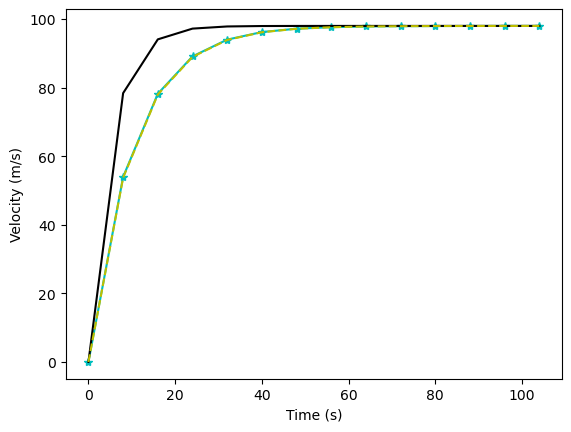

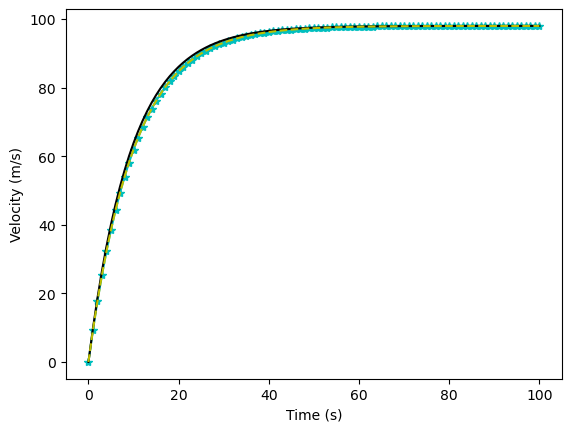

In [53]:
v0 = 0
#h = 8, larger step size
h = 8
t_array_8 = np.arange(0,100+h,h)
v_act_8 = v(t_array_8,b,m,v0)
v_eul_8 = euler(t_array_8,h,v0,f)
v_rk4_8 = RK4(t_array_8,h,v0,f)
#h = 1, smaller step size
h = 1 
t_array_1 = np.arange(0,100+h,h)
v_act_1 = v(t_array_1,b,m,v0)
v_eul_1 = euler(t_array_1,h,v0,f)
v_rk4_1 = RK4(t_array_1,h,v0,f)

#Plotting our results
plt.plot(t_array_8,v_act_8,"c*-")
plt.plot(t_array_8,v_eul_8,"k-")
plt.plot(t_array_8,v_rk4_8,"y--")
#Making it look nice
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

#Plotting our results
plt.plot(t_array_1,v_act_1,"c*-")
plt.plot(t_array_1,v_eul_1,"k-")
plt.plot(t_array_1,v_rk4_1,"y--")
#Making it look nice
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

#### Explanation Markdown Cell: 

Noticeably for the smaller step size of $h=1$ it is hard to tell the difference between the different methods and that of the actual velocity - which makes sense as we are reducing our error. Then for the larger step size of $h=8$ the RK4 method is noticeably more accurate than the Euler's method.